# Agentic Workflows (LangGraph)

A **stateful agent** built as a graph, able to call tools and perform live web search to complete multi-step tasks.

**What it demonstrates**
- Modelling agent logic as an explicit state graph (nodes, edges, state)
- Giving an agent tools, including Tavily web search
- Current LangChain/LangGraph APIs (updated from older tutorial imports)

**Stack:** Python · LangGraph · LangChain · Tavily · Gradio


In [1]:
import os
import uuid
import getpass
from typing import TypedDict, Annotated, Sequence, List, Tuple, Optional, Any, Union, Literal,  Tuple
from datetime import date
import operator
from IPython.display import display, Markdown
from graphviz import Source
import uuid


from langchain_openai import ChatOpenAI
from langchain_tavily import TavilySearch
from langchain_core.messages import BaseMessage, ToolMessage, HumanMessage, AIMessage, SystemMessage
from langchain_core.tools import tool
from pydantic import BaseModel

from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode
from langchain.agents import create_agent

import gradio as gr

from dotenv import load_dotenv
load_dotenv()

openai_api_key = os.getenv("OPENAI_API_KEY")

print("OpenAI API Key loaded successfully.")

OpenAI API Key loaded successfully.


In [2]:
def print_markdown(text: str):
    display(Markdown(text))

In [3]:
class AgentState(TypedDict):
    input_text: str
    summary: str

In [4]:
def summarize_step(state: AgentState) -> AgentState:
    

    llm = ChatOpenAI(model="gpt-3.5-turbo")
    prompt = f"Please summarize the following text in one sentence that captures the main points: {state['input_text']}"

    result = llm.invoke([prompt])
    
    return {
        "input_text": state["input_text"],
        "summary": result.content 
    }

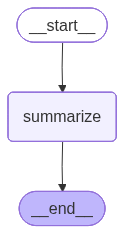

In [5]:
workflow = StateGraph(AgentState)

workflow.add_node("summarize", summarize_step)
workflow.add_edge("summarize", END)
workflow.set_entry_point("summarize")
workflow.compile()

In [7]:
sample_text = """
    Electric cars work by using electricity stored in a battery pack to power an electric motor, which drives the wheels. 
    Unlike gasoline-powered vehicles that rely on internal combustion engines, electric vehicles (EVS) use electric motors that are more efficient and produce zero emissions during operation. 
    When you press the accelerator, the battery sends power to the motor, which instantly provides torque to move the car. 
    The battery is recharged by plugging the car into an external power source, such as a home charger or public charging station. 
    Some electric cars also feature regenerative braking, which captures energy during braking and feeds it back into the battery to improve efficiency.
    """

graph = workflow.compile()

initial_state = {
    "input_text": sample_text,
    "summary": ""
}

result = graph.invoke(initial_state)

summary = result["summary"]

print_markdown(summary)

Electric cars use electricity stored in a battery pack to power an electric motor, providing efficient operation with zero emissions, and are recharged by plugging into external power sources, with some models also featuring regenerative braking to improve efficiency.

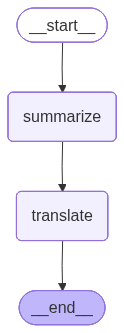

In [ ]:
class AgentState(TypedDict):
    input_text: str
    summary: str
    translated_summary: str

def translate_step(state: AgentState) -> AgentState:

    llm = ChatOpenAI(model = "gpt-4o-mini")
    prompt = f"Please translate the following summary into Spanish: {state['summary']}"

    result = llm.invoke([prompt])


    return {
        "input_text": state["input_text"], 
        "summary": state["summary"],
        "translated_summary": result.content
    }

workflow = StateGraph(AgentState)

workflow.add_node("summarize", summarize_step)

workflow.add_edge("summarize", "translate")

workflow.add_node("translate", translate_step)

workflow.set_entry_point("summarize")

workflow.compile()

In [10]:
sample_text = """
    Electric cars are awesome! I love them so much! They work by using electricity stored in a battery pack to power an electric motor, which drives the wheels. 
    Unlike gasoline-powered vehicles that rely on internal combustion engines, electric vehicles (EVS) use electric motors that are more efficient and produce zero emissions during operation. 
    When you press the accelerator, the battery sends power to the motor, which instantly provides torque to move the car. 
    The battery is recharged by plugging the car into an external power source, such as a home charger or public charging station. 
    Some electric cars also feature regenerative braking, which captures energy during braking and feeds it back into the battery to improve efficiency.
    """

graph = workflow.compile()

initial_state = {
    "input_text": sample_text,
    "summary": "",
    "translated_summary": ""
}

result = graph.invoke(initial_state)
translated_summary = result["translated_summary"]
summary = result["summary"]

print("====Generated Summary====")
print_markdown(summary)
print("====Translated Summary====")
print_markdown(translated_summary)

====Generated Summary====


Electric cars use electricity stored in battery packs to power electric motors, providing efficient and emissions-free transportation through the use of regenerative braking and external power sources for recharging.

====Translated Summary====


Los coches eléctricos utilizan electricidad almacenada en baterías para alimentar motores eléctricos, proporcionando un transporte eficiente y libre de emisiones a través del uso de frenos regenerativos y fuentes externas de energía para la recarga.

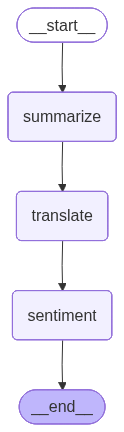

In [20]:
class AgentState(TypedDict):
    input_text: str
    summary: str
    translated_summary: str
    sentiment: str


def analyze_sentiment_step(state: AgentState) -> AgentState:

    llm = ChatOpenAI(model = "gpt-4o-mini")
    prompt = f"Please analyze the sentiment of the following text. Return only one of the following: positive, negative, or neutral: {state['summary']}"

    result = llm.invoke([prompt])


    return {
        "input_text": state["input_text"], 
        "summary": state["summary"],
        "translated_summary": state["translated_summary"],
        "sentiment": result.content
    }

workflow = StateGraph(AgentState)

workflow.add_node("summarize", summarize_step)

workflow.add_edge("summarize", "translate")

workflow.add_node("translate", translate_step)

workflow.add_edge("translate", "sentiment")

workflow.add_node("sentiment", analyze_sentiment_step)

workflow.set_entry_point("summarize")

workflow.compile()

In [21]:
sample_text = """
    Electric cars are awesome! I love them so much! They work by using electricity stored in a battery pack to power an electric motor, which drives the wheels. 
    Unlike gasoline-powered vehicles that rely on internal combustion engines, electric vehicles (EVS) use electric motors that are more efficient and produce zero emissions during operation. 
    When you press the accelerator, the battery sends power to the motor, which instantly provides torque to move the car. 
    The battery is recharged by plugging the car into an external power source, such as a home charger or public charging station. 
    Some electric cars also feature regenerative braking, which captures energy during braking and feeds it back into the battery to improve efficiency.
    """

graph = workflow.compile()

initial_state = {
    "input_text": sample_text,
    "summary": "",
    "translated_summary": "",
    "sentiment": ""
}

result = graph.invoke(initial_state)
translated_summary = result["translated_summary"]
summary = result["summary"]
sentiment = result["sentiment"]

print("====Generated Summary====")
print_markdown(summary)
print("====Translated Summary====")
print_markdown(translated_summary)
print("====Analyzed Sentiment====")
print_markdown(sentiment)

====Generated Summary====


Electric cars operate using electricity stored in a battery that powers an electric motor to drive the wheels, offering a more efficient and environmentally friendly alternative to gasoline-powered vehicles.

====Translated Summary====


Los coches eléctricos funcionan con electricidad almacenada en una batería que alimenta un motor eléctrico para mover las ruedas, ofreciendo una alternativa más eficiente y ecológica a los vehículos que funcionan con gasolina.

====Analyzed Sentiment====


Positive

In [22]:
# Define the shared state structure
class AgentState(TypedDict):
    input_text: str
    summary: str
    translated_summary: str
    sentiment: str  # <- state key

# Summarize step
def summarize_step(state: AgentState) -> AgentState:
    llm = ChatOpenAI(model="gpt-4o-mini")
    prompt = f"Summarize this text:\n\n{state['input_text']}"
    result = llm.invoke([prompt])
    return {
        **state, # The syntax **state in Python means you're unpacking a dictionary — spreading out its key-value pairs.
        # Take everything from state (like "input_text", "summary", etc.). Then overwrite the "sentiment" key with a new value
        "summary": result.content
    }

# Translate step
def translate_step(state: AgentState) -> AgentState:
    llm = ChatOpenAI(model="gpt-4o-mini")
    prompt = f"Please translate from English to Spanish: {state['summary']}"
    result = llm.invoke([prompt])
    return {
        **state,
        "translated_summary": result.content
    }

# Sentiment step
def sentiment_step(state: AgentState) -> AgentState:
    llm = ChatOpenAI(model="gpt-4o-mini")
    prompt = f"Classify the sentiment of the following text as positive, negative, or neutral:\n\n{state['input_text']}"
    result = llm.invoke([prompt])
    return {
        **state,
        "sentiment": result.content.strip()
    }

# Define the graph
workflow = StateGraph(AgentState)

# Add nodes (use unique names)
workflow.add_node("summarize", summarize_step)
workflow.add_node("translate", translate_step)
workflow.add_node("analyze_sentiment", sentiment_step)  # Renamed to avoid conflict

# Define edges
workflow.add_edge("summarize", "translate")
workflow.add_edge("translate", "analyze_sentiment")  # Use renamed node

# Set entry point
workflow.set_entry_point("summarize")

# Compile the graph
graph = workflow.compile()

# Sample input
sample_text = """
Electric cars work by using electricity stored in a battery pack to power an electric motor, which drives the wheels. 
Unlike gasoline-powered vehicles that rely on internal combustion engines, electric vehicles (EVs) use electric motors that are more efficient and produce zero emissions during operation. 
When you press the accelerator, the battery sends power to the motor, which instantly provides torque to move the car. 
The battery is recharged by plugging the car into an external power source, such as a home charger or public charging station. 
Some electric cars also feature regenerative braking, which captures energy during braking and feeds it back into the battery to improve efficiency.
"""

# Initial state
initial_state = {
    "input_text": sample_text,
    "summary": "",
    "translated_summary": "",
    "sentiment": ""
}

# Run the workflow
result = graph.invoke(initial_state)

# Display results
print("=== Generated Summary ===")
print_markdown(result["summary"])

print("\n=== Translated Summary ===")
print_markdown(result["translated_summary"])

print("\n=== Sentiment ===")
print_markdown(result["sentiment"])

=== Generated Summary ===


Electric cars operate by using electricity from a battery to power an electric motor that drives the wheels, making them more efficient than gasoline-powered vehicles, which use internal combustion engines. When the accelerator is pressed, the battery provides instant power to the motor. The battery can be recharged by plugging the car into an external power source. Many electric cars also include regenerative braking, which recaptures energy during braking to enhance efficiency.


=== Translated Summary ===


Los coches eléctricos funcionan utilizando electricidad de una batería para alimentar un motor eléctrico que impulsa las ruedas, lo que los hace más eficientes que los vehículos de gasolina, que utilizan motores de combustión interna. Cuando se pisa el acelerador, la batería proporciona potencia instantánea al motor. La batería se puede recargar conectando el coche a una fuente de energía externa. Muchos coches eléctricos también incluyen frenos regenerativos, que recapturan energía durante el frenado para mejorar la eficiencia.


=== Sentiment ===


The sentiment of the text is neutral. It primarily provides factual information about how electric cars work without expressing any positive or negative opinion.

In [25]:
import os
from dotenv import load_dotenv

load_dotenv() 

tavily_api_key = os.getenv("TAVILY_API_KEY")
print(f"Tavily Key starts with: {tavily_api_key[:5]}...")

Tavily Key starts with: tvly-...


In [26]:
llm = ChatOpenAI(model= "gpt-4.1-mini", temperature = 0, streaming = True)

print("LangChain OpenAI Chat Model configured.")

LangChain OpenAI Chat Model configured.


In [47]:
class AgentState(TypedDict):

    messages: Annotated[Sequence[BaseMessage], operator.add]

In [48]:
from langchain_tavily import TavilySearch


tavily_search_tools = TavilySearch(max_results = 3)

tool_list_single = [tavily_search_tools]

In [49]:
def make_call_model_with_tools(tools: list):
    def call_model_with_tools(state: AgentState):
        print("DEBUG: Entering call_model_with_tools node")
        messages = state["messages"]

        model_with_tools = llm.bind_tools(tools)

        response = model_with_tools.invoke(messages)

        return {
            "messages": [response]
        }
    return call_model_with_tools

In [51]:
def should_continue(state: AgentState) -> Literal["action", "__end__"]:
    """Determines the next step: continue with tools or end."""
    print("DEBUG: Entering should_continue node")

    last_message = state["messages"][-1]

    if isinstance(last_message, AIMessage) and hasattr(last_message, "tool_calls") and last_message.tool_calls:
        print("DEBUG: Decision: continue (route to action)")
        return "action"  # Route to the node named "action"
    else:
        print("DEBUG: Decision: end (route to END)")
        return END  # Special value indicating the end of the graph

In [52]:
from langgraph.prebuilt import ToolNode

from IPython.display import Image, display

def build_graph_one_tool(tools_list): 
    
    tool_node = ToolNode(tools_list)

    call_node_fn = make_call_model_with_tools(tools_list)

    graph_one_tool = StateGraph(AgentState)

    graph_one_tool.add_node("agent", call_node_fn)

    graph_one_tool.add_node("action", tool_node)

    graph_one_tool.set_entry_point("agent")

    graph_one_tool.add_conditional_edges(
        "agent",
        should_continue,
        {"action": "action", END: END}
    )

    graph_one_tool.add_edge("action", "agent")

    app = graph_one_tool.compile()

    display(Image(app.get_graph().draw_mermaid_png()))

    return app

In [53]:
def app_call(app, messages):

    initial_state = {"messages": [HumanMessage(content=messages)]}

    final_state = app.invoke(initial_state)

    for i in final_state["messages"]:
        print_markdown(i.type)
        print_markdown(i.content)
        if i.additional_kwargs != {}:
            print(i.additional_kwargs)

    return final_state["messages"][-1].content, final_state

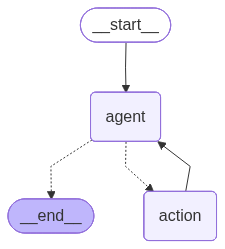

In [54]:
app = build_graph_one_tool(tool_list_single)

In [57]:
messages = "What's the latest news on Iran in June 2026? Is it a good time to visit?"
output, history = app_call(app, messages)

print("\n==================== OUTPUT ====================")
print(output)

print("\n==================== HISTORY ===================")
print(history)

DEBUG: Entering call_model_with_tools node
DEBUG: Entering should_continue node
DEBUG: Decision: continue (route to action)
DEBUG: Entering call_model_with_tools node
DEBUG: Entering should_continue node
DEBUG: Decision: end (route to END)


human

What's the latest news on Iran in June 2026? Is it a good time to visit?

ai

tool

{"query": "latest news on Iran June 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://en.mehrnews.com/news/245404/Iran-taken-lawful-steps-in-self-defense-against-aggression", "title": "Iran taken lawful steps in self-defense against aggression - Mehr News Agency", "score": 0.9296516, "published_date": "Wed, 17 Jun 2026 10:13:27 GMT", "content": "Jun 17, 2026\n\n Telegram\n Instagram\n Twitter\n facebook\n RSS\n Archive\n\n \n Jun 17, 2026, 1:43 PM\n News ID 245404\n 1. Politics\n\nJun 17, 2026, 1:43 PM\n\n# Iran taken lawful steps in self-defense against aggression\n\nTEHRAN, Jun. 17 (MNA) – Iran’s UN ambassador dismissed the Israeli regime’s baseless accusations against Iran, arguing that Tehran’s recent military actions were lawful and proportionate measures taken in self-defense against US-Israeli aggression.\n\nIn a letter to UN Secretary General António Guterres and President of the UN Security Council Leonor Zalabata Torres on June 12, Saeed Iravani rejected claims made by the Zionist regime in a recent communication to the Council. [...] Excellency,\n\nI am writing with reference to the letter dated 9 June 2026 from the representative of the Israeli regime addressed to the President of the Security Council (S/2026/474), in which the regime once again resorts to falsehoods, distortions, and unfounded allegations against the Islamic Republic of Iran in a futile attempt to justify its unlawful conduct and acts of aggression against Iran. In this regard, I wish to draw the attention of Your Excellency and the members of the Security Council to the following: [...] 2. The claims made in the letter constitute a deliberate attempt to distort the facts and mislead the international community. The actions undertaken by Iran on 7 June 2026 were proportionate lawful acts of self-defense conducted in the context of the Israeli regime's repeated violations of the ceasefire of 8 April 2026 and its continuing wrongful acts against the Islamic Republic of Iran, including its direct complicity with the United States in attacks against Iranian vessels, civilian infrastructure, and targets in Iran, as well as acts of maritime piracy directed against the Iranian nation. In response to these continuing internationally wrongful acts, the Armed Forces of the Islamic Republic of Iran targeted a number of Israeli military objectives. These measures were undertaken in", "raw_content": null}, {"url": "https://english.aawsat.com/world/5284250-irans-fars-news-agency-says-hormuz-maritime-fees-added-us-deal-last-minute", "title": "Iran's Fars News Agency Says Hormuz Maritime Fees Added to US Deal Last Minute - Asharq Al-Awsat English", "score": 0.8991304, "published_date": "Mon, 15 Jun 2026 09:25:52 GMT", "content": "An Iranian woman walks past an anti-Israeli mural, after US and Iranian officials said they had reached a deal to end their war and reopen the Strait of Hormuz, in Tehran, Iran, June 15, 2026. Majid Asgaripour/WANA (West Asia News Agency) via Reuters\n\nTT\n\nTT\n\n## UN Human Rights Chief Welcomes US-Iran Deal, Urges Restraint in the Region\n\nAn Iranian woman walks past an anti-Israeli mural, after US and Iranian officials said they had reached a deal to end their war and reopen the Strait of Hormuz, in Tehran, Iran, June 15, 2026. Majid Asgaripour/WANA (West Asia News Agency) via Reuters\n\nThe United Nations' human rights chief on Monday welcomed the announcement of a peace deal between the United States and Iran, and urged for maximum restraint by all sides in the region. [...] Asharq Al Awsat\n\nTT\n\n Asharq Al Awsat\n\nTT\n\n## Iran's Fars News Agency Says Hormuz Maritime Fees Added to US Deal Last Minute\n\nVessels at the Strait of Hormuz, as seen from Musandam, Oman, June 14, 2026. REUTERS/Stringer\n\nIran's Fars news agency said on Monday, quoting what it said was an informed source, that Tehran added a clause on imposing maritime service fees to the framework deal with the United States shortly before its announcement.\n\n\"In the final moments of the negotiations, the text of the memorandum of understanding was amended to clearly and explicitly emphasize the issue of the Iranian-Omani sovereignty over the Strait of Hormuz,\" said Fars, citing the unidentified source. [...] عربي English Türkçe اردو فارسى\n\n Gulf\n Arab World\n World\n Opinion\n Interviews\n Varieties\n Business\n Culture\n Sports\n Entertainment\n Fashion\n Features\n Technology\n\nعربي English Türkçe اردو فارسى\n\nLatest News\n\n Saudi Arabia, Ireland Agree to Strengthen Air Transport Cooperation\n OIC Hails US-Iran Agreement to End Military Operations and Restore Hormuz Navigation\n Arab League Secretary-General Welcomes Announcement of US-Iran MoU\n\nIran's Fars News Agency Says Hormuz Maritime Fees Added to US Deal Last Minute \n\n# Iran's Fars News Agency Says Hormuz Maritime Fees Added to US Deal Last Minute\n\nVessels at the Strait of Hormuz, as seen from Musandam, Oman, June 14, 2026. REUTERS/Stringer\n\n Asharq Al Awsat\n\nTT\n\n Asharq Al Awsat\n\nTT", "raw_content": null}, {"url": "https://english.aawsat.com/world/5284266-iran-executed-18-protesters-2026-says-un", "title": "Iran Executed 18 Protesters in 2026, Says UN - Asharq Al-Awsat English", "score": 0.86136365, "published_date": "Mon, 15 Jun 2026 10:09:06 GMT", "content": "TT\n\nTT\n\n## Iran Executed 18 Protesters in 2026, Says UN\n\nUN High Commissioner for Human Rights Volker Turk speaks to the media, at the Office of the United Nations High Commissioner for Human Rights (OHCHR) Palais Wilson, in Geneva, Switzerland, Wednesday, June 10, 2026. (Keystone via AP)\n\nIran has executed at least 40 people, including 18 protesters, on \"national security grounds\" since the start of 2026, the United Nations said Monday.\n\nUN rights chief Volker Turk said he felt \"deeply for the people in Iran, caught between war and cruel repression\".\n\nSince the start of the year, the Iranian authorities \"have executed at least 40 people on national security grounds... including 18 protesters\", he told the UN Human Rights Council. [...] عربي English Türkçe اردو فارسى\n\n Gulf\n Arab World\n World\n Opinion\n Interviews\n Varieties\n Business\n Culture\n Sports\n Entertainment\n Fashion\n Features\n Technology\n\nعربي English Türkçe اردو فارسى\n\nLatest News\n\n US-Iran Deal to Be Signed in Switzerland on Friday, Says Bern\n China Warns Next Phase of US-Iran Talks Will Be ‘More Difficult’\n Israeli Military Takes More Territory, Kills Two People in Gaza, Medics and Witnesses Say\n\nIran Executed 18 Protesters in 2026, Says UN \n\n# Iran Executed 18 Protesters in 2026, Says UN\n\nUN High Commissioner for Human Rights Volker Turk speaks to the media, at the Office of the United Nations High Commissioner for Human Rights (OHCHR) Palais Wilson, in Geneva, Switzerland, Wednesday, June 10, 2026. (Keystone via AP)\n\nTT\n\nTT [...] World\n\n# China Warns Next Phase of US-Iran Talks Will Be ‘More Difficult’\n\nTankers and cargo vessels are seen in the Gulf of Oman, along shipping routes linking the Strait of Hormuz and the Arabian Sea, Tuesday, June 16, 2026. (AP)\n\nTT\n\nTT\n\n## China Warns Next Phase of US-Iran Talks Will Be ‘More Difficult’\n\nTankers and cargo vessels are seen in the Gulf of Oman, along shipping routes linking the Strait of Hormuz and the Arabian Sea, Tuesday, June 16, 2026. (AP)\n\nChina's top diplomat told his Pakistani counterpart on Tuesday that the next phase of negotiations between the United States and Iran -- which Pakistan has helped mediate -- will be \"more difficult\".", "raw_content": null}], "response_time": 0.92, "request_id": "737148ed-2975-400a-bc07-345af79fae77"}

ai

The latest news on Iran in June 2026 highlights several key points:

1. Iran has taken lawful steps in self-defense against aggression, particularly in response to actions by the Israeli regime and the United States. Iran's military actions are described as proportionate and lawful measures in self-defense against repeated violations and attacks.

2. A significant development is the announcement of a peace deal between the United States and Iran, which includes reopening the Strait of Hormuz. However, Iran added a clause on imposing maritime service fees to the framework deal shortly before its announcement.

3. The United Nations has reported that Iran has executed at least 40 people, including 18 protesters, on national security grounds since the start of 2026, indicating ongoing internal repression.

4. China has warned that the next phase of US-Iran negotiations will be more difficult, suggesting ongoing diplomatic challenges.

Regarding whether it is a good time to visit Iran, the situation appears complex. While there is a peace deal with the US and some diplomatic progress, there are also reports of military tensions and internal repression. Travelers should exercise caution, stay informed about the security situation, and consider travel advisories from their home countries before planning a visit to Iran at this time.


==================== OUTPUT ====================
The latest news on Iran in June 2026 highlights several key points:

1. Iran has taken lawful steps in self-defense against aggression, particularly in response to actions by the Israeli regime and the United States. Iran's military actions are described as proportionate and lawful measures in self-defense against repeated violations and attacks.

2. A significant development is the announcement of a peace deal between the United States and Iran, which includes reopening the Strait of Hormuz. However, Iran added a clause on imposing maritime service fees to the framework deal shortly before its announcement.

3. The United Nations has reported that Iran has executed at least 40 people, including 18 protesters, on national security grounds since the start of 2026, indicating ongoing internal repression.

4. China has warned that the next phase of US-Iran negotiations will be more difficult, suggesting ongoing diplomatic challenges.

Rega

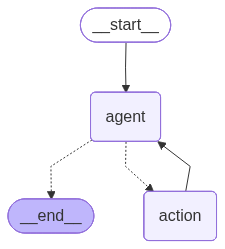

DEBUG: Entering call_model_with_tools node
DEBUG: Entering should_continue node
DEBUG: Decision: continue (route to action)
DEBUG: Entering call_model_with_tools node
DEBUG: Entering should_continue node
DEBUG: Decision: end (route to END)


human

What is the current date?

ai

tool

2026-06-18

ai

The current date is June 18, 2026.

In [58]:
@tool

def get_current_date_tool():
    """Returns the current date in the 'YYYY-MM-DD' format. Useful for finding flights/hotels relative to today"""
    return date.today().isoformat()


app_current_date = build_graph_one_tool([get_current_date_tool])


prompt = "What is the current date?"
output, history = app_call(app_current_date, prompt)
